## 1. Purpose

Workbook for the two gradient-descent-trained models (DNN and PINN, no-environment
feature set) — the sklearn/Chapman-Richards baselines already have their own results
notebook (`baseline_results.ipynb`) and this one deliberately doesn't duplicate that,
since none of the four baselines use gradient descent and so have no loss curves to
look at.

This notebook only *reads* what's already saved under `outputs/` — it never trains or
evaluates anything itself. See section 2 below for exactly which scripts to run first.

Three things this notebook is for:
1. Plotting training/validation loss curves once a real (not sanity-check) training
   run exists.
2. A results table comparing DNN/PINN against the `temporal_split` baseline numbers,
   so a new run's metrics are always read next to the numbers they're actually being
   compared against.
3. A running record of what's been tried and what to try next — the parameter-tuning
   equivalent of `documentation/experiment_log.md`'s Findings log, but focused
   specifically on DNN/PINN hyperparameters rather than the project as a whole.

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import plot_loss_curve

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
NEURAL_MODELS = ["dnn_noenv", "pinn_noenv"]

OUTPUTS_DIR = project_root / "outputs"

# DNN/PINN only ever train under temporal_split, so their output path has no
# split-type prefix (see documentation/experiment_log.md's naming convention).
# The baselines were re-run under every split type, so their temporal-split
# numbers specifically -- the ones DNN/PINN should be compared against --
# live under outputs/temporal/<model>/<cohort>/, not the plain outputs/<model>/<cohort>/
# (which is the plot_level result).
BASELINE_MODELS_TEMPORAL = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]

## 2. Which files to run, to (re)compile these results

1. **Push cleaned data to the cluster** (`data/processed/` is gitignored, never
   travels via git): `rsync` `data/processed/master/*.parquet` to the cluster, then
   there run `python -m data_processing.export_model_tables` to regenerate
   `data/processed/current_state/` on that machine.
2. **Fit, on the cluster (GPU)**:
   `python -m models.dnn_noenv.run_dnn_noenv --cohort <4survey|6survey> --max-epochs 500`
   and the same for `models.pinn_noenv.run_pinn_noenv`. Omit `--cohort` to run both.
   This is the FIT-only step — it never touches the test split. Saves checkpoints,
   scalers, `training_history.csv`, `run_metadata.json` under `outputs/<model>/<cohort>/`.
3. **Pull results back**: `rsync` `outputs/dnn_noenv/`, `outputs/pinn_noenv/`, and
   `outputs/run_logs/` from the cluster down to the laptop.
4. **Evaluate, locally (cheap, CPU)**:
   `python -m models.dnn_noenv.evaluate_dnn_noenv` and
   `python -m models.pinn_noenv.evaluate_pinn_noenv` (omit `--cohort` for both). This
   is what actually writes the real `metrics.json`/`predictions.csv` this notebook
   reads below.

Before trusting a result read below as real: check `run_metadata.json`'s
`max_epochs` for that run wasn't a quick sanity check (see
`documentation/progress_notes.md`, "Checking a run is good, not just present").

## 3. Training / validation loss curves

One panel per model per cohort. `train_loss`/`val_loss` are always plotted;
`data_loss`/`physics_loss`/`trajectory_loss` are added automatically for the PINN
(see `models/common/plotting.py::plot_loss_curve`). The dotted vertical line marks
the best epoch — the one `load_best_model()` actually loads, not necessarily the
last epoch trained.

**As of writing this notebook, only 2-epoch sanity-check runs exist** (see
`documentation/experiment_log.md`'s Findings log, "Pending" entry) — these curves are
not yet meaningful, just here to confirm the plotting works. Re-run this section
after a real `--max-epochs 500` run to see the actual result.

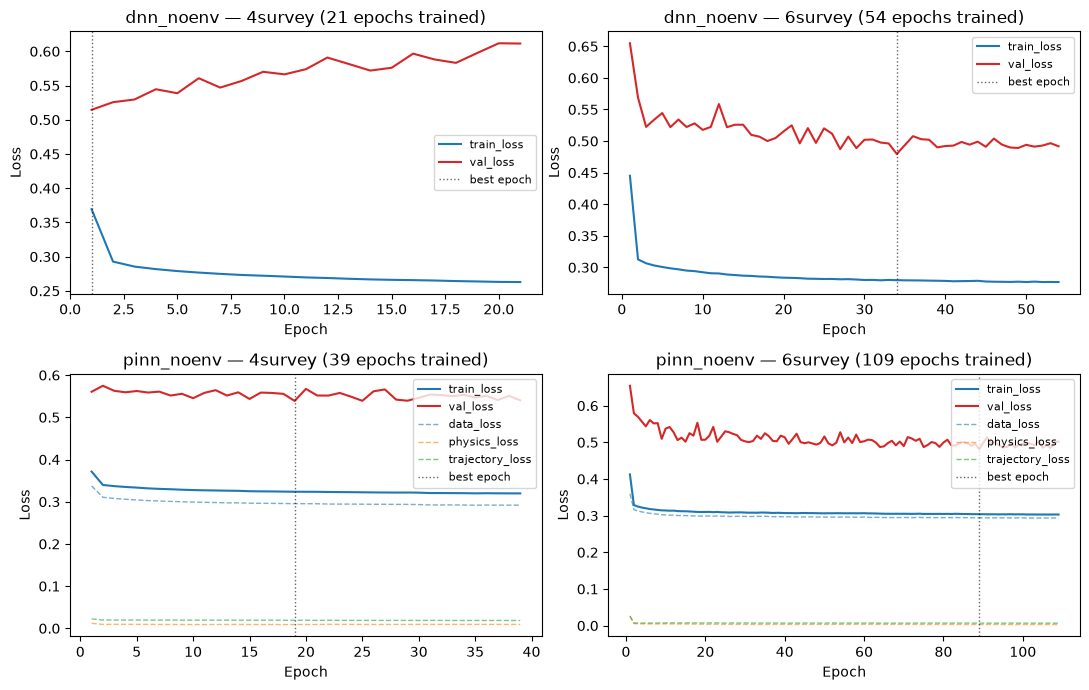

In [3]:
fig, axes = plt.subplots(len(NEURAL_MODELS), len(COHORTS), figsize=(11, 7))

for row, model_name in enumerate(NEURAL_MODELS):
    for col, cohort in enumerate(COHORTS):
        ax = axes[row, col]
        history_path = OUTPUTS_DIR / model_name / cohort / "training_history.csv"
        if not history_path.exists():
            ax.set_title(f"{model_name} / {cohort} — no training_history.csv yet")
            continue
        history_df = pd.read_csv(history_path)
        plot_loss_curve(history_df, ax=ax)
        ax.set_title(f"{model_name} — {cohort} ({len(history_df)} epochs trained)")

fig.tight_layout()
plt.show()

## 4. Test-set metrics: DNN/PINN vs. the temporal-split baselines

Reads whatever `metrics.json` currently exists for each model — real numbers once the
full-length runs have been evaluated, sanity-check numbers until then (check
`run_metadata.json`'s `max_epochs` if unsure which one you're looking at).

In [4]:
def load_metrics(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


rows = []
for cohort in COHORTS:
    for model_name in BASELINE_MODELS_TEMPORAL:
        metrics = load_metrics(OUTPUTS_DIR / "temporal" / model_name / cohort / "metrics.json")
        if metrics is not None:
            rows.append({"cohort": cohort, "model": model_name, **metrics})
    for model_name in NEURAL_MODELS:
        metrics = load_metrics(OUTPUTS_DIR / model_name / cohort / "metrics.json")
        if metrics is not None:
            rows.append({"cohort": cohort, "model": model_name, **metrics})

metrics_table = pd.DataFrame(rows)[["cohort", "model", "mae", "rmse", "r2", "bias", "accuracy_pct"]]
metrics_table.sort_values(["cohort", "rmse"])

,cohort,model,mae,rmse,r2,bias,accuracy_pct
4,4survey,dnn_noenv,4.607954,5.864798,0.452423,0.318159,77.060348
5,4survey,pinn_noenv,4.860543,6.074789,0.412509,0.571382,75.364232
2,4survey,linear_baseline,5.120562,6.346717,0.358736,1.007022,75.291856
0,4survey,chapman_richards,6.429910,7.613991,0.077081,2.066302,68.563393
3,4survey,rf_baseline,6.136230,7.807253,0.029634,1.276056,70.781733
1,4survey,average_by_age,7.230844,8.809688,-0.235549,2.713745,65.771570
11,6survey,pinn_noenv,3.561120,4.771705,0.323166,1.082947,84.154232
10,6survey,dnn_noenv,3.734936,4.918168,0.280979,1.231806,83.647167
9,6survey,rf_baseline,4.179781,5.349440,0.149349,1.682205,82.405894
6,6survey,chapman_richards,4.733138,5.748186,0.017808,2.827067,80.541791


## 5. Experiments run so far (DNN/PINN specifically)

Full detail and the reasoning chain live in `documentation/experiment_log.md`'s
Findings log — this section is a short pointer, not a duplicate.

- **Baselines under `temporal_split`** (2026-07-15): far larger degradation than under
  `spatial_block_split` — up to +141.7% RMSE for some models, `average_by_age`'s R²
  went negative on 6survey. Chapman-Richards (the physically-constrained model)
  degraded the *least* — this is the direct empirical motivation for the PINN.
- **DNN/PINN pipeline smoke tests** (2026-07-15/16, 2-epoch sanity checks only):
  confirmed the fit → evaluate → run-log pipeline works end-to-end for both models,
  both cohorts, including the physics-loss terms producing sensible nonzero values
  for the PINN. Not a real result — see `experiment_log.md`'s status column.
- **Age filter** (2026-07-15/16): re-verified on a real cluster run of the baselines;
  DNN/PINN already used the same filter by default (`filter_data()`'s
  `maturity_age_min=30`), so nothing needed re-running because of this.
- **Not yet run**: the actual full-length (`--max-epochs 500`) training for either
  model. Nothing below section 6 can be treated as a real conclusion until that
  exists.

## 6. Ideas for parameter tuning (once a real run exists)

Concrete things to check once `training_history.csv` reflects a real, full-length run
— not conclusions yet, just what to look for and what to try if a problem shows up.

| What to check in the loss curve | If you see this... | ...try this |
|---|---|---|
| `val_loss` vs `train_loss` gap | `val_loss` plateaus or rises early while `train_loss` keeps falling (overfitting) | increase `L1_COEFFICIENT`, add dropout, or reduce `NoEnvNetwork`'s width/depth (`models/common/torch_model.py`) |
| `val_loss` shape | never really improves, both losses flat from the start (underfitting / stuck) | raise `LEARNING_RATE`, check `LR_SCHEDULER_PATIENCE`/`LR_SCHEDULER_FACTOR` aren't shrinking it too fast, or widen the network |
| best epoch vs. total trained | best epoch is very early (as in the current 2-epoch smoke test — epoch 1 was already best) and training runs long past it without improving | this may just resolve itself with more real epochs and a longer runway before `early_stopping_patience` kicks in; if not, the learning rate may be too high early on |
| PINN's `physics_loss`/`trajectory_loss` vs `data_loss` | one term numerically dominates the combined `train_loss` and the network mostly optimises that instead of fitting the data | re-tune `PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` (`models/pinn_noenv/pinn_noenv.py`) so no single term swamps the others |
| PINN's `physics_loss`/`trajectory_loss` going to ~0 immediately | the physics terms aren't actually constraining anything (trivially satisfied) | check they're computed against the *unscaled* CR curve correctly, and that `frozen_cr_params` in `run_metadata.json` are sensible, not degenerate |
| DNN vs PINN comparison, once both are real | PINN's test RMSE isn't better than the DNN's under `temporal_split` | this would be a genuine, reportable negative result, not a bug to hunt for — the whole point of running this comparison is that it wasn't guaranteed to work; also worth checking Route B (`documentation/experiment_log.md`'s planned robustness checks) in case Route A's CR anchor is the weak point, not the PINN idea itself |

Also planned (see `experiment_log.md`'s "Planned robustness checks" table, not yet
triggered): temporal split Design 2, and the PINN's Route B CR anchor.